In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from ant.market import Market, BaseAgent
from ant.decentralised.direct import ProportionalAgent, GreedyAgent
from ant.centralised import P4

In [2]:
# Demo experiment
market_size = 500
seed = 25
G = nx.gnp_random_graph(market_size, 0.11, seed=seed)

# Create different markets with the same topology and agent endowment and resource value (same seed is used)
# All markets use a different (homogenous) strategy
M1: Market = Market(market_size, graph=G, seed=seed, agent_type=ProportionalAgent)
M2: Market = Market(market_size, graph=G, seed=seed, agent_type=GreedyAgent)

In [3]:
allocation_matrix, utility = computed_equilibrium = P4(M1)

/home/joeri/Projects/RP/Ant/src/ant/centralised.py:50: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  result = prob.solve()


In [7]:
simulation_length = 400
M1.set_market_equilibrium(allocation_matrix, utility)
M2.set_market_equilibrium(allocation_matrix, utility)

simulated_state_proportional = M1.simulate(simulation_length)
simulated_state_greedy = M2.simulate(simulation_length)

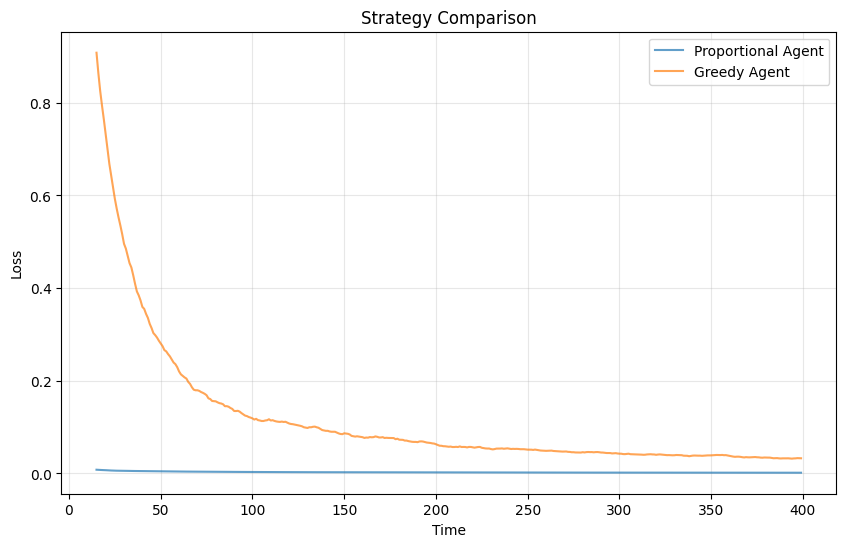

In [8]:
training_period = 15
time_steps = np.arange(training_period, simulation_length)

plt.figure(figsize=(10, 6))
plt.plot(
    time_steps,
    simulated_state_proportional[training_period:],
    label="Proportional Agent",
    alpha=0.7,
)
plt.plot(
    time_steps,
    simulated_state_greedy[training_period:],
    label="Greedy Agent",
    alpha=0.7,
)

plt.xlabel("Time")
plt.ylabel("Loss")
plt.title("Strategy Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()